In [ ]:
#import csv file which shows the funding to settlement agencies across Ontario. 
# This was downloaded from https://data.ontario.ca/dataset/newcomer-settlement-program/resource/fbc17217-ba79-403a-815b-996322787532
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('/Users/anthoniaaina/Desktop/DSI/visualization/02_activities/assignments/2013_Housing.csv')

print(data.info()) # Check the structure of the dataset
print(data.head()) # Display the first few rows of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Organization Name     112 non-null    object
 1   Organization Website  107 non-null    object
 2   Location              111 non-null    object
 3   Address Line 1        111 non-null    object
 4   Address Line 2        8 non-null      object
 5   Province              111 non-null    object
 6   Postal Code           111 non-null    object
 7   Phone Number          111 non-null    object
 8   Grant Amount          111 non-null    object
 9   Fiscal Year           111 non-null    object
dtypes: object(10)
memory usage: 9.0+ KB
None


In [ ]:
data["Grant Amount"] = (
    data["Grant Amount"]
    .astype(str)
    .str.replace(",", "", regex=False) # Remove commas from "Grant Amount" column
    .str.replace("$", "", regex=False)) # Remove dollar signs from "Grant Amount" column

data["Grant Amount"] = pd.to_numeric(data["Grant Amount"], errors="coerce") # Convert "Grant Amount" column to numeric, coercing errors to NaN
data = data.dropna(subset=["Grant Amount", "Location"]) # Drop rows with NaN values in "Grant Amount" or "Location" columns

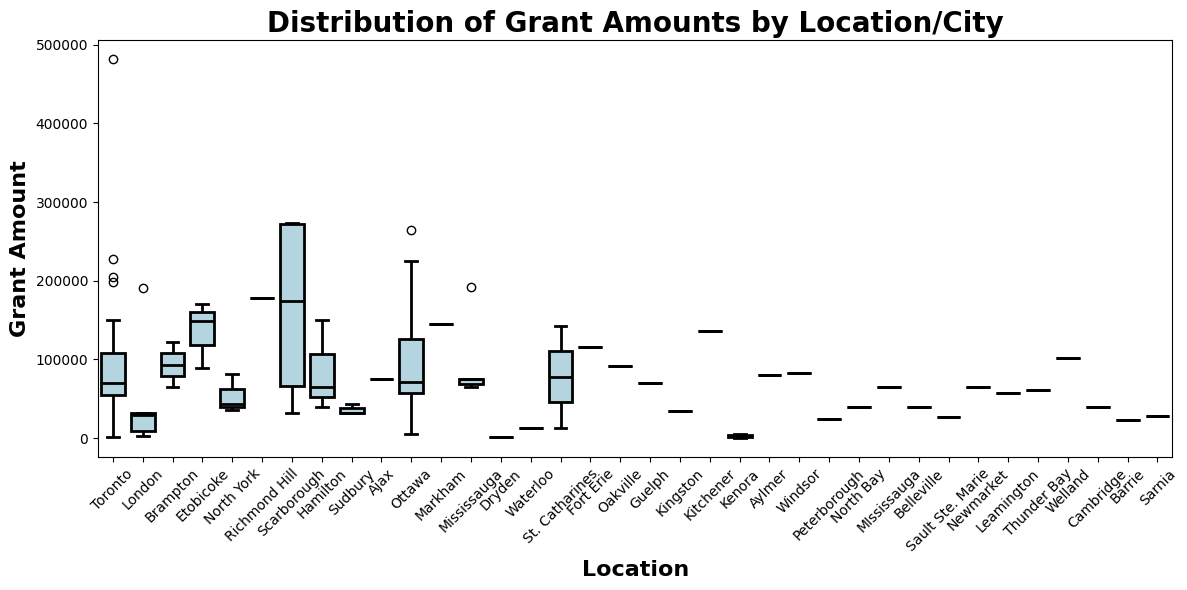

In [ ]:
#BOX PLOT FOR GRANT AMOUNT DISTRIBUTION BY LOCATION
plt.figure(figsize=(12, 6)) # Set figure size
sns.boxplot(x="Location", y="Grant Amount", data=data, color="lightblue", linecolor="black", linewidth=2) # Create box plot of Grant Amount by Location. 
#The lines represent the quartiles and median of the data and the whiskers extend to show the rest of the distribution, except for points that are determined to be "outliers" using a method that is a function of the inter-quartile range.
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.title("Distribution of Grant Amounts by Location/City", fontsize=20, fontweight='bold', color='Black') # Set plot title
plt.xlabel("Location", fontsize=16, fontweight='bold', color='Black') # Set x-axis label
plt.ylabel("Grant Amount",fontsize=16, fontweight='bold', color='Black') # Set y-axis label
plt.tight_layout()
plt.show()


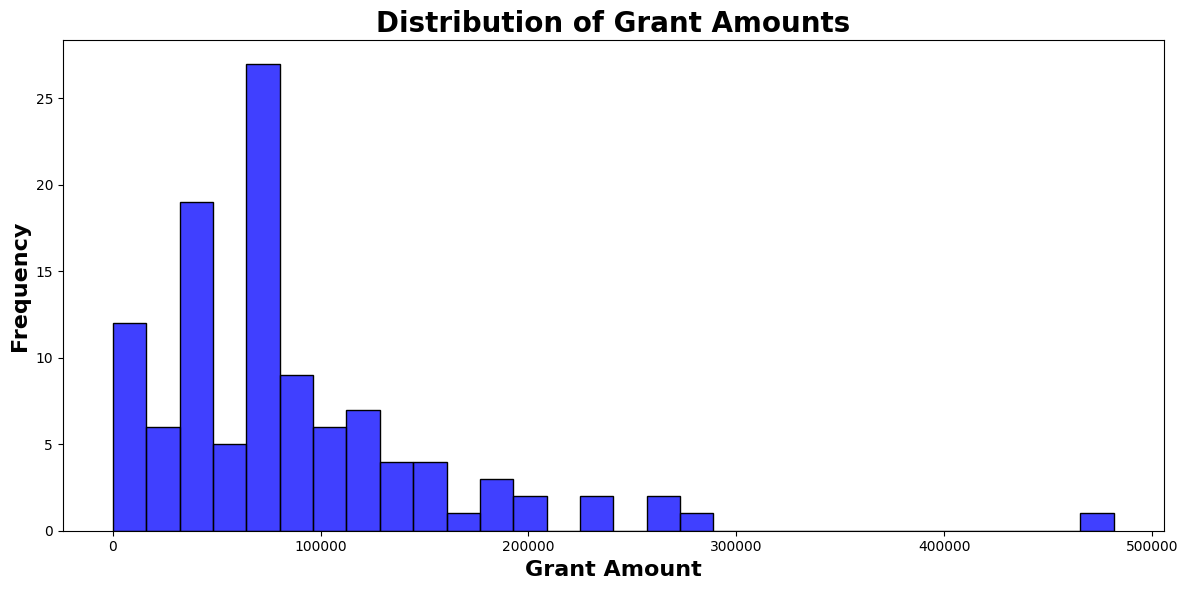

In [104]:
#HISTOGRAM PLOT FOR GRANT AMOUNT
#Note, I PLOTED THIS IN EXCEL FIRST AND THEN REPLICATED IT IN PYTHON (SCREENSHOT ATTACHED)
plt.figure(figsize=(12, 6)) # Set figure size
sns.histplot(data=data, x="Grant Amount", bins=30, color="blue", edgecolor="black") 
#Histogram of Grant Amount. the bins represent intervals of Grant Amount values and the height of each bin represents the frequency of data points within that interval.
plt.title("Distribution of Grant Amounts", fontsize=20, fontweight='bold', color='Black')
plt.xlabel("Grant Amount", fontsize=16, fontweight='bold', color='Black')
plt.ylabel("Frequency", fontsize=16, fontweight='bold', color='Black')
plt.tight_layout()
plt.show()